In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Colours
AIRBNB_RED   = '#FF5A5F'
AIRBNB_TEAL  = '#00A699'
AIRBNB_DARK  = '#484848'
AIRBNB_LIGHT = '#767676'
PALETTE      = [AIRBNB_RED, AIRBNB_TEAL, '#FC642D', '#FFB400', '#007A87', '#8CE071']
 
sns.set_theme(style='whitegrid', font_scale=1.05)
 
 
# ── 1. LOAD DATA
searches = pd.read_csv('/kaggle/input/datasets/omkarrsurve/dublin-airbnb/searches.tsv', sep='\t',
                        parse_dates=['ds', 'ds_checkin', 'ds_checkout'])
 
contacts = pd.read_csv('/kaggle/input/datasets/omkarrsurve/dublin-airbnb/contacts.tsv', sep='\t',
                        parse_dates=['ts_contact_at', 'ts_reply_at',
                                     'ts_accepted_at', 'ts_booking_at',
                                     'ds_checkin', 'ds_checkout'])
 
print(f'searches : {searches.shape}')
print(f'contacts : {contacts.shape}')
print('\nsearches dtypes:\n', searches.dtypes)
print('\ncontacts dtypes:\n', contacts.dtypes)

searches : (35737, 13)
contacts : (7823, 11)

searches dtypes:
 ds                      datetime64[ns]
id_user                         object
ds_checkin              datetime64[ns]
ds_checkout             datetime64[ns]
n_searches                       int64
n_nights                       float64
n_guests_min                     int64
n_guests_max                     int64
origin_country                  object
filter_price_min               float64
filter_price_max               float64
filter_room_types               object
filter_neighborhoods            object
dtype: object

contacts dtypes:
 id_guest                  object
id_host                   object
id_listing                object
ts_contact_at     datetime64[ns]
ts_reply_at       datetime64[ns]
ts_accepted_at    datetime64[ns]
ts_booking_at     datetime64[ns]
ds_checkin        datetime64[ns]
ds_checkout       datetime64[ns]
n_guests                   int64
n_messages                 int64
dtype: object


In [3]:
# ── 2. PREPARE — SEARCHES 
searches['checkin_dow']       = searches['ds_checkin'].dt.day_name()
searches['checkin_month']     = searches['ds_checkin'].dt.month_name()
searches['checkin_month_num'] = searches['ds_checkin'].dt.month
searches['n_nights']          = searches['n_nights'].clip(upper=30)
searches['has_price_filter']  = searches['filter_price_min'].notna()
searches['has_room_filter']   = searches['filter_room_types'].notna()
searches['has_nbhd_filter']   = searches['filter_neighborhoods'].notna()
searches['lead_time']         = (searches['ds_checkin'] - searches['ds']).dt.days.clip(0, 180)
 
print('\n[Searches] new columns:')
searches[['checkin_dow','checkin_month','checkin_month_num',
          'n_nights','has_price_filter','lead_time']].head(3)
 



[Searches] new columns:


,checkin_dow,checkin_month,checkin_month_num,n_nights,has_price_filter,lead_time
0,Thursday,October,10.0,3.0,True,8.0
1,Thursday,October,10.0,10.0,True,8.0
2,NaN,NaN,NaN,NaN,False,NaN


In [4]:
# ── 3. PREPARE — CONTACTS 
contacts['replied']           = contacts['ts_reply_at'].notna()
contacts['accepted']          = contacts['ts_accepted_at'].notna()
contacts['booked']            = contacts['ts_booking_at'].notna()
contacts['n_nights_c']        = (contacts['ds_checkout'] - contacts['ds_checkin']).dt.days.clip(upper=30)
contacts['checkin_dow']       = contacts['ds_checkin'].dt.day_name()
contacts['checkin_month']     = contacts['ds_checkin'].dt.month_name()
contacts['checkin_month_num'] = contacts['ds_checkin'].dt.month
contacts['resp_hours']        = ((contacts['ts_reply_at'] - contacts['ts_contact_at'])
                                  .dt.total_seconds() / 3600).clip(0, 100)

In [5]:
reply_rate   = contacts['replied'].mean()
accept_rate  = contacts['accepted'].mean()
booking_rate = contacts['booked'].mean()
 
print(f'\nFunnel → reply {reply_rate:.1%}  |  accept {accept_rate:.1%}  |  book {booking_rate:.1%}')
print('\n[Contacts] new columns:')
contacts[['replied','accepted','booked','n_nights_c','checkin_dow','resp_hours']].head(3)


Funnel → reply 92.3%  |  accept 46.4%  |  book 27.8%

[Contacts] new columns:


,replied,accepted,booked,n_nights_c,checkin_dow,resp_hours
0,True,True,True,2,Monday,0.000000
1,True,True,True,3,Thursday,0.596389
2,True,False,False,2,Friday,3.069722


In [6]:
# ── 4. NIGHT DURATION BINS 
bins   = [0, 1, 2, 3, 4, 5, 7, 10, 14, 31]
labels = ['1', '2', '3', '4', '5', '6-7', '8-10', '11-14', '15+']
 
searches['nights_bin']   = pd.cut(searches['n_nights'],   bins=bins, labels=labels)
contacts['nights_bin_c'] = pd.cut(contacts['n_nights_c'], bins=bins, labels=labels)
 

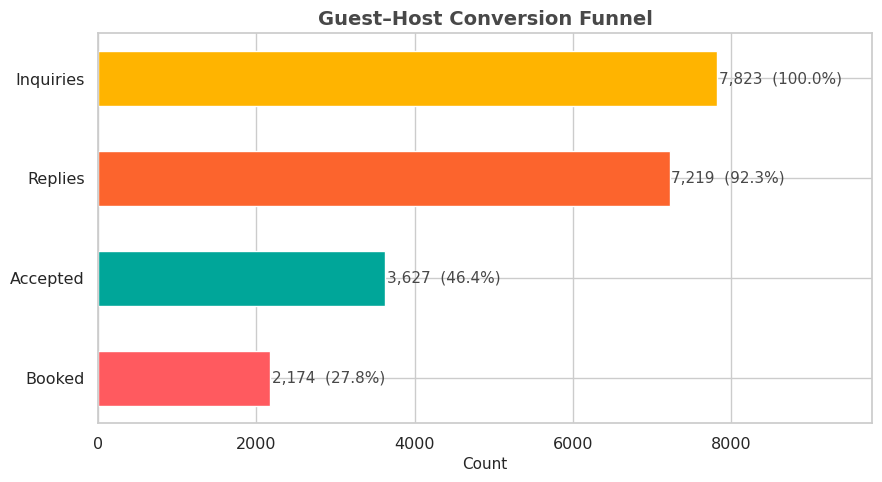

In [7]:
# CHART 1 — CONVERSION FUNNEL

stages = ['Inquiries', 'Replies', 'Accepted', 'Booked']
counts = [len(contacts),
          contacts['replied'].sum(),
          contacts['accepted'].sum(),
          contacts['booked'].sum()]
pcts   = [c / counts[0] * 100 for c in counts]
 
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(stages[::-1], counts[::-1], color=PALETTE[:4], height=0.55, edgecolor='white')
for bar, p, c in zip(bars, pcts[::-1], counts[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f'{c:,}  ({p:.1f}%)', va='center', fontsize=11, color=AIRBNB_DARK)
ax.set_xlabel('Count', fontsize=11)
ax.set_title('Guest–Host Conversion Funnel', fontsize=14, fontweight='bold', color=AIRBNB_DARK)
ax.set_xlim(0, counts[0] * 1.25)
ax.tick_params(left=False)
plt.tight_layout()


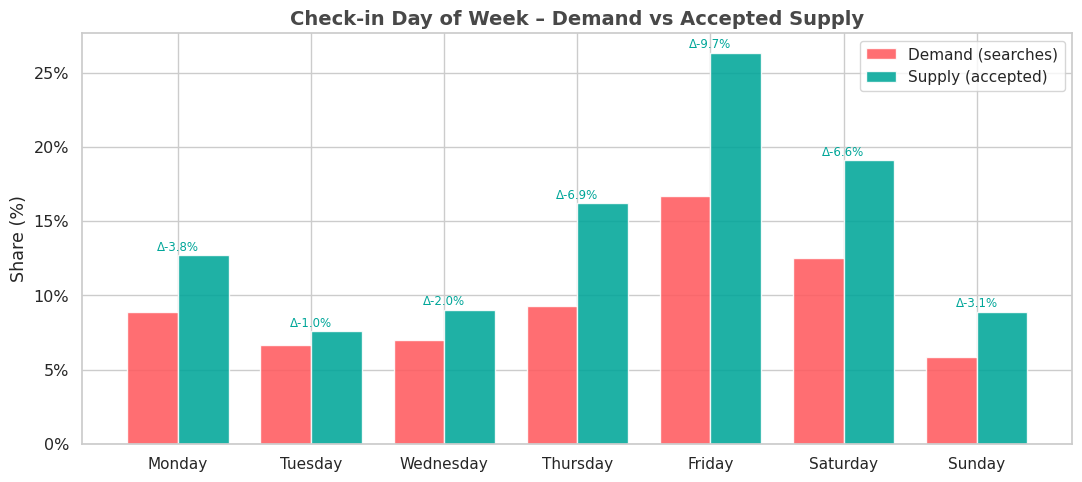

In [8]:
# CHART 2 — CHECK-IN DAY OF WEEK

DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
 
demand_dow = (searches.groupby('checkin_dow').size() / len(searches) * 100).reindex(DOW_ORDER)
supply_dow = (contacts[contacts['accepted']].groupby('checkin_dow').size() /
              contacts['accepted'].sum() * 100).reindex(DOW_ORDER)
 
x = np.arange(len(DOW_ORDER))
w = 0.38
 
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, demand_dow, width=w, label='Demand (searches)',  color=AIRBNB_RED,  alpha=0.88)
ax.bar(x + w/2, supply_dow, width=w, label='Supply (accepted)',  color=AIRBNB_TEAL, alpha=0.88)
ax.set_xticks(x)
ax.set_xticklabels(DOW_ORDER, fontsize=11)
ax.set_ylabel('Share (%)')
ax.set_title('Check-in Day of Week – Demand vs Accepted Supply', fontsize=14, fontweight='bold', color=AIRBNB_DARK)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
for xi, d, s in zip(x, demand_dow, supply_dow):
    gap = d - s
    if abs(gap) > 0.5:
        ax.annotate(f'Δ{gap:+.1f}%', xy=(xi, max(d, s) + 0.3),
                    ha='center', fontsize=8.5, color='#e05000' if gap > 0 else AIRBNB_TEAL)
plt.tight_layout()

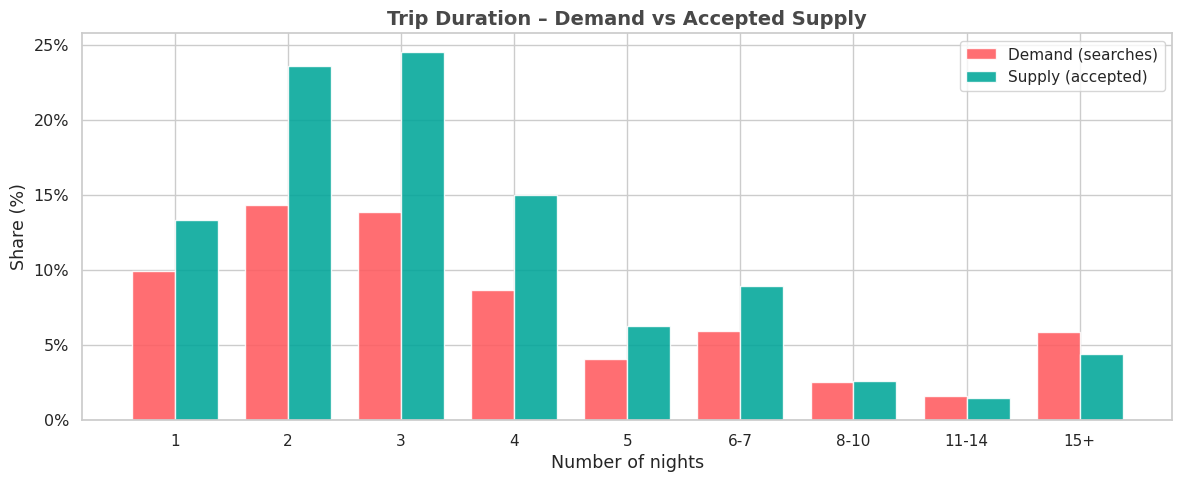

In [9]:
# CHART 3 — NUMBER OF NIGHTS

demand_nights = searches.groupby('nights_bin', observed=True).size() / len(searches) * 100
supply_nights = (contacts[contacts['accepted']]
                 .groupby('nights_bin_c', observed=True).size() /
                 contacts['accepted'].sum() * 100)
 
demand_nights = demand_nights.reindex(labels, fill_value=0)
supply_nights = supply_nights.reindex(labels, fill_value=0)
 
x = np.arange(len(labels))
w = 0.38
 
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, demand_nights, width=w, label='Demand (searches)',  color=AIRBNB_RED,  alpha=0.88)
ax.bar(x + w/2, supply_nights, width=w, label='Supply (accepted)',  color=AIRBNB_TEAL, alpha=0.88)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_xlabel('Number of nights')
ax.set_ylabel('Share (%)')
ax.set_title('Trip Duration – Demand vs Accepted Supply', fontsize=14, fontweight='bold', color=AIRBNB_DARK)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()

filter_room_types
Entire home/apt    43.691955
                   30.931130
Private room       21.674104
Shared room         3.702810
Other               0.000000
Name: proportion, dtype: float64


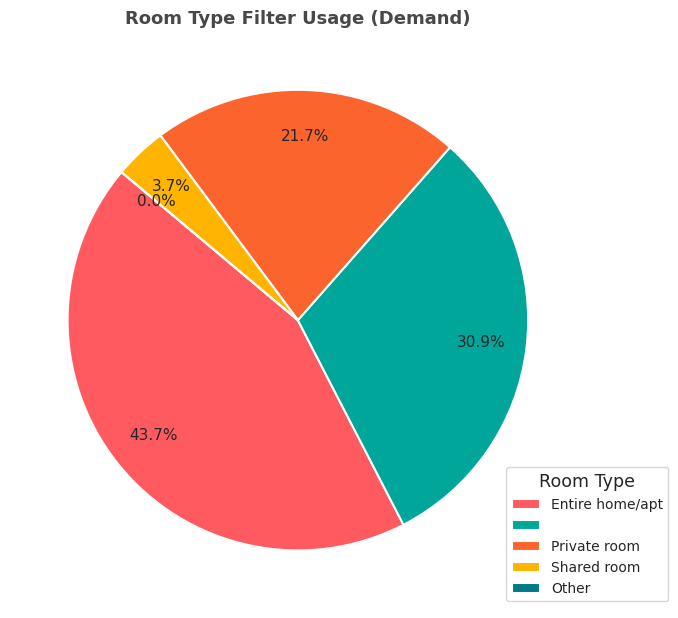

In [10]:
room_series = (searches['filter_room_types']
               .dropna()
               .str.strip()                    # remove extra spaces
               .str.lower()                    # lowercase everything
               .str.split(','))                # split "A,B" into ['A','B']

# Step 2 — explode so each room type gets its own row
room_exploded = room_series.explode().str.strip()

# Step 3 — standardise names
room_exploded = room_exploded.replace({
    'entire home/apt'  : 'Entire home/apt',
    'private room'     : 'Private room',
    'shared room'      : 'Shared room',
    'hotel room'       : 'Hotel room',
})

# Step 4 — count
room_demand = room_exploded.value_counts(normalize=True) * 100

# Step 5 — top 5 + Other
top5 = room_demand.head(5)
top5['Other'] = room_demand.iloc[5:].sum()

print(top5)  # verify before plotting

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    top5,
    labels=None,
    autopct='%1.1f%%',
    startangle=140,
    colors=PALETTE,
    pctdistance=0.80,
    wedgeprops=dict(edgecolor='white', linewidth=1.5))

for t in autotexts:
    t.set_fontsize(11)

ax.legend(wedges, top5.index,
          title='Room Type',
          loc='lower left',
          bbox_to_anchor=(0.85, 0, 0.5, 1),
          fontsize=10)

ax.set_title('Room Type Filter Usage (Demand)',
             fontsize=13, fontweight='bold', color=AIRBNB_DARK)
fig.tight_layout()

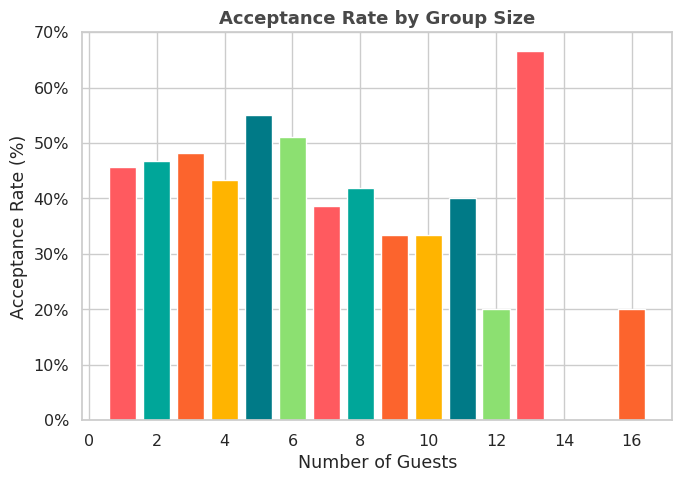

In [11]:
acc_guests = contacts.groupby('n_guests').agg(
    total=('accepted', 'count'),
    accepted=('accepted', 'sum')).reset_index()
acc_guests['rate'] = acc_guests['accepted'] / acc_guests['total'] * 100

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(acc_guests['n_guests'], acc_guests['rate'], color=PALETTE, edgecolor='white')
ax.set_xlabel('Number of Guests')
ax.set_ylabel('Acceptance Rate (%)')
ax.set_title('Acceptance Rate by Group Size', fontsize=13, fontweight='bold', color=AIRBNB_DARK)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
fig.tight_layout()

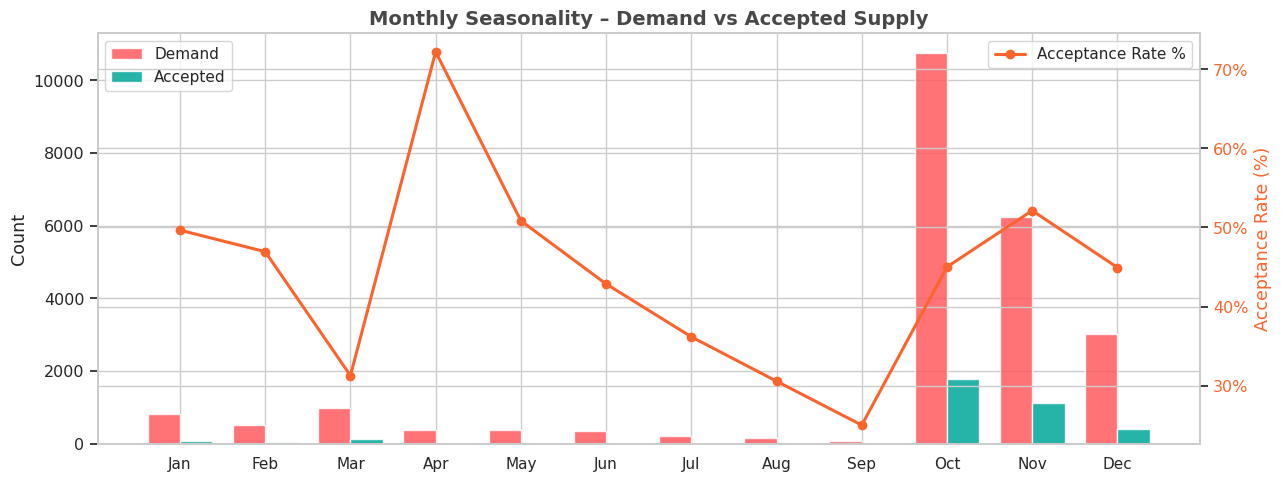

In [12]:
# CHART 5 — MONTHLY SEASONALITY
MONTH_ORDER = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
 
demand_mon = searches.groupby('checkin_month').size().reindex(MONTH_ORDER)
supply_mon = (contacts[contacts['accepted']]
              .groupby('checkin_month').size().reindex(MONTH_ORDER))
all_mon    = contacts.groupby('checkin_month')['accepted'].agg(['sum','count']).reindex(MONTH_ORDER)
acc_rate_m = all_mon['sum'] / all_mon['count'] * 100
 
x = np.arange(len(MONTH_ORDER))
w = 0.38
 
fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.bar(x - w/2, demand_mon, width=w, label='Demand',   color=AIRBNB_RED,  alpha=0.85)
ax1.bar(x + w/2, supply_mon, width=w, label='Accepted', color=AIRBNB_TEAL, alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels([m[:3] for m in MONTH_ORDER], fontsize=11)
ax1.set_ylabel('Count')
ax1.set_title('Monthly Seasonality – Demand vs Accepted Supply', fontsize=14, fontweight='bold', color=AIRBNB_DARK)
ax1.legend(loc='upper left', fontsize=11)
 
ax2 = ax1.twinx()
ax2.plot(x, acc_rate_m, color='#FC642D', marker='o', linewidth=2.2, label='Acceptance Rate %', zorder=5)
ax2.set_ylabel('Acceptance Rate (%)', color='#FC642D')
ax2.tick_params(axis='y', labelcolor='#FC642D')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.legend(loc='upper right', fontsize=11)
plt.tight_layout()

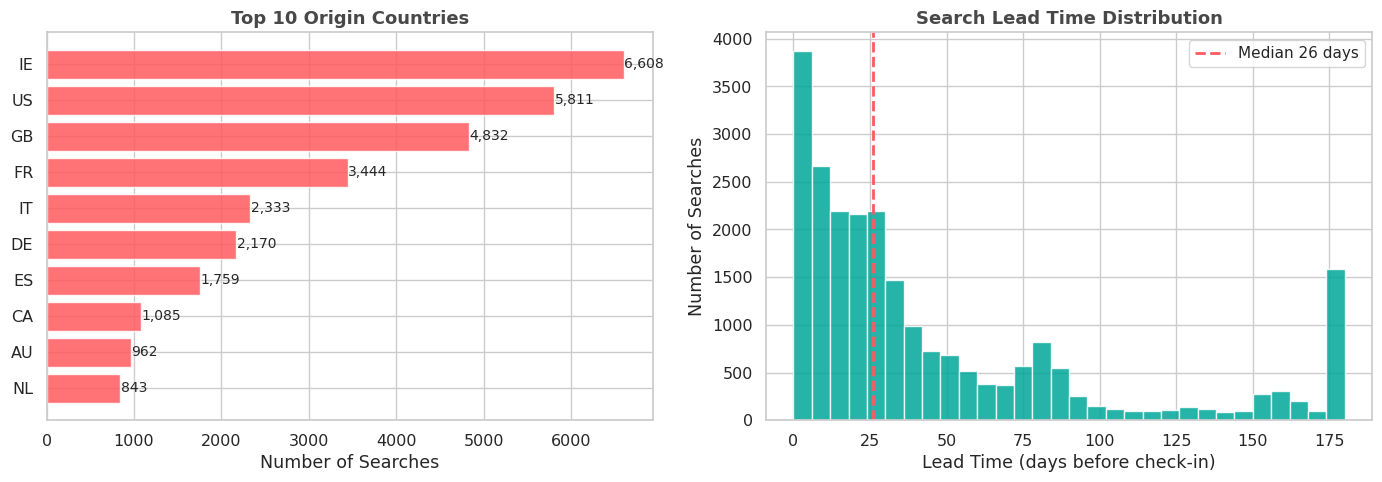

In [13]:
# CHART 6 — ORIGIN COUNTRIES & LEAD TIME
top_countries = searches['origin_country'].value_counts().head(10)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Bar — top countries
axes[0].barh(top_countries.index[::-1], top_countries.values[::-1],
             color=AIRBNB_RED, alpha=0.85)
axes[0].set_xlabel('Number of Searches')
axes[0].set_title('Top 10 Origin Countries', fontsize=13, fontweight='bold', color=AIRBNB_DARK)
for i, (c, v) in enumerate(zip(top_countries.index[::-1], top_countries.values[::-1])):
    axes[0].text(v + 5, i, f'{v:,}', va='center', fontsize=10)
 
# Histogram — lead time
axes[1].hist(searches['lead_time'], bins=30, color=AIRBNB_TEAL, edgecolor='white', alpha=0.85)
axes[1].axvline(searches['lead_time'].median(), color=AIRBNB_RED,
                linewidth=2, linestyle='--',
                label=f'Median {searches["lead_time"].median():.0f} days')
axes[1].set_xlabel('Lead Time (days before check-in)')
axes[1].set_ylabel('Number of Searches')
axes[1].set_title('Search Lead Time Distribution', fontsize=13, fontweight='bold', color=AIRBNB_DARK)
axes[1].legend(fontsize=11)
plt.tight_layout()

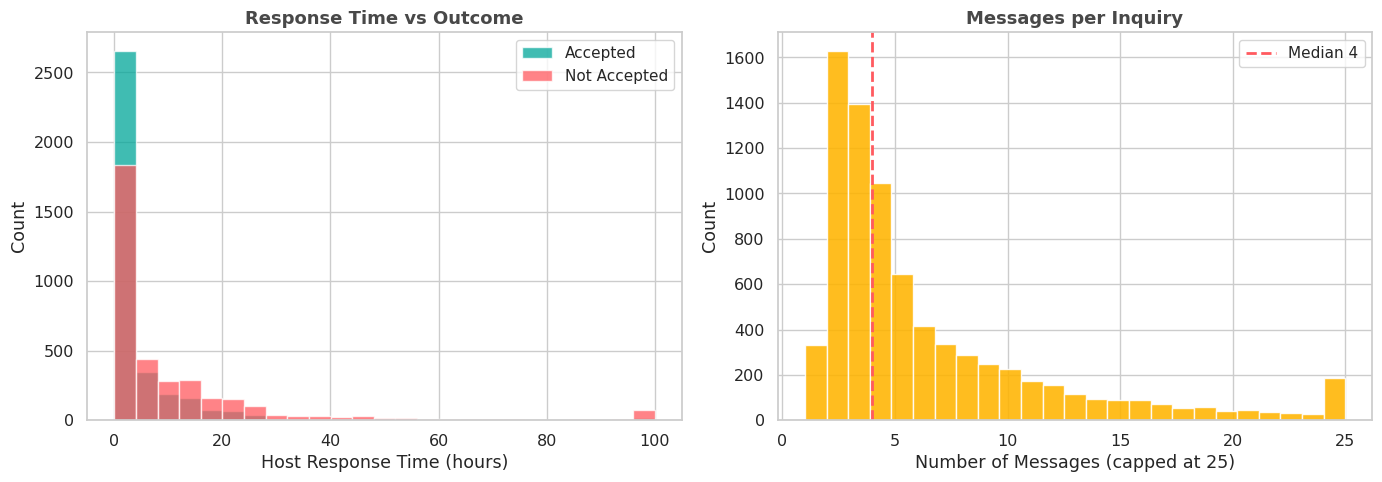

In [14]:
# CHART 7 — HOST RESPONSE TIME & MESSAGES
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Response time by outcome
axes[0].hist(contacts.loc[contacts['accepted'],        'resp_hours'].dropna(),
             bins=25, alpha=0.75, color=AIRBNB_TEAL, label='Accepted')
axes[0].hist(contacts.loc[~contacts['accepted'] & contacts['replied'], 'resp_hours'].dropna(),
             bins=25, alpha=0.75, color=AIRBNB_RED,  label='Not Accepted')
axes[0].set_xlabel('Host Response Time (hours)')
axes[0].set_ylabel('Count')
axes[0].set_title('Response Time vs Outcome', fontsize=13, fontweight='bold', color=AIRBNB_DARK)
axes[0].legend(fontsize=11)
 
# Messages per inquiry
msg_cap = contacts['n_messages'].clip(upper=25)
axes[1].hist(msg_cap, bins=25, color='#FFB400', edgecolor='white', alpha=0.88)
axes[1].axvline(msg_cap.median(), color=AIRBNB_RED, linewidth=2, linestyle='--',
                label=f'Median {msg_cap.median():.0f}')
axes[1].set_xlabel('Number of Messages (capped at 25)')
axes[1].set_ylabel('Count')
axes[1].set_title('Messages per Inquiry', fontsize=13, fontweight='bold', color=AIRBNB_DARK)
axes[1].legend(fontsize=11)
plt.tight_layout()

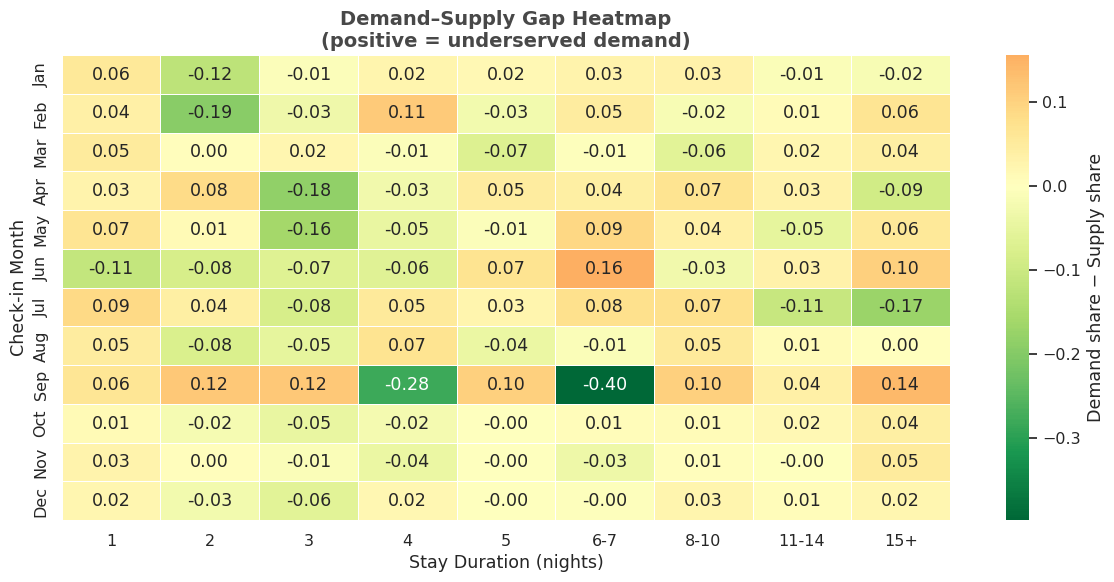

In [15]:
# CHART 8 — DEMAND–SUPPLY GAP HEATMAP (month × nights)
MONTHS_SHORT = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
 
d_pivot = (searches.groupby(['checkin_month_num','nights_bin'], observed=True)
           .size().unstack(fill_value=0))
s_pivot = (contacts[contacts['accepted']]
           .groupby(['checkin_month_num','nights_bin_c'], observed=True)
           .size().unstack(fill_value=0))
s_pivot.columns.name = 'nights_bin'
 
d_norm = d_pivot.div(d_pivot.sum(axis=1), axis=0)
s_norm = s_pivot.div(s_pivot.sum(axis=1), axis=0)
gap    = (d_norm - s_norm).fillna(0)
gap.index = MONTHS_SHORT
 
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(gap, cmap='RdYlGn_r', center=0, linewidths=0.4,
            linecolor='white', annot=True, fmt='.2f',
            cbar_kws={'label': 'Demand share − Supply share'}, ax=ax)
ax.set_xlabel('Stay Duration (nights)')
ax.set_ylabel('Check-in Month')
ax.set_title('Demand–Supply Gap Heatmap\n(positive = underserved demand)',
             fontsize=14, fontweight='bold', color=AIRBNB_DARK)
plt.tight_layout()

In [16]:
# SUMMARY STATS
print('SUMMARY STATISTICS')
print(f'\n[Searches]')
print(f'  Total searches       : {len(searches):,}')
print(f'  Unique users         : {searches["id_user"].nunique():,}')
print(f'  Median nights        : {searches["n_nights"].median():.0f}')
print(f'  Median lead time     : {searches["lead_time"].median():.0f} days')
print(f'  Price filter usage   : {searches["has_price_filter"].mean():.1%}')
print(f'  Room filter usage    : {searches["has_room_filter"].mean():.1%}')
print(f'  Nbhd filter usage    : {searches["has_nbhd_filter"].mean():.1%}')
print(f'\n[Contacts]')
print(f'  Total inquiries      : {len(contacts):,}')
print(f'  Reply rate           : {reply_rate:.1%}')
print(f'  Acceptance rate      : {accept_rate:.1%}')
print(f'  Booking rate         : {booking_rate:.1%}')
print(f'  Median messages      : {contacts["n_messages"].median():.0f}')
print('═' * 55)

══ SUMMARY STATISTICS ════════════════════════════════════════════════

[Searches]
  Total searches       : 35,737
  Unique users         : 18,605
  Median nights        : 3
  Median lead time     : 26 days
  Price filter usage   : 37.3%
  Room filter usage    : 45.3%
  Nbhd filter usage    : 3.8%

[Contacts]
  Total inquiries      : 7,823
  Reply rate           : 92.3%
  Acceptance rate      : 46.4%
  Booking rate         : 27.8%
  Median messages      : 4
═══════════════════════════════════════════════════════
